# Пример 01. Бинарная операция и её свойства

## Тема

**Раздел книги:** Линейная алгебра (группа 2).  
**Математическая тема:** бинарные операции, алгебраические структуры, проверка свойств операции; связь групповых структур с методом главных компонент (PCA).

## Условие

Рассматривается бинарная операция вида $a \star b = a\cdot b + a + b$, заданная на множестве действительных чисел. Требуется проверить её поведение на конкретных значениях, а затем сопоставить эту абстрактную конструкцию с практической задачей декорреляции данных в методе главных компонент.

## Математическая идея

Бинарная операция $\star\colon \mathbb{R}\times\mathbb{R}\to\mathbb{R}$ определяется как

$$a \star b = a b + a + b.$$

Эту операцию удобно переписать через сдвиг на единицу:

$$a \star b + 1 = (a+1)(b+1),$$

откуда

$$a \star b = (a+1)(b+1) - 1.$$

Такая форма показывает, что операция $\star$ изоморфна обычному умножению на множестве $\mathbb{R}\setminus\{-1\}$, что позволяет переносить свойства умножения (ассоциативность, коммутативность, наличие нейтрального элемента $0$) на $\star$.

## Решение

Подставляя конкретные значения, вычислим результат последовательного применения операции. Например, для $x_1 = 1$:

$$3 \star x_1 = 3\cdot 1 + 3 + 1 = 7,\quad (3\star x_1)\star x_1 = 7 \star 1 = 7\cdot 1 + 7 + 1 = 15.$$

Аналогично для $x_2 = -3$ операция применяется дважды с учётом знаков. Полученные числовые значения используются как sanity-check реализации.

## Реализация на Python

Функция `star(a, b)` реализует введённую бинарную операцию напрямую по формуле. Последовательное применение `star(star(3, x), x)` вычисляет выражение $(3\star x)\star x$ для двух различных значений $x$. Дальнейшая часть Notebook'а демонстрирует, как похожая идея — переход к новой системе координат, в которой структура данных становится проще — применяется в PCA: исходные коррелированные данные преобразуются так, чтобы ковариационная матрица стала диагональной.


In [2]:
def star(a, b):
    return a * b + a + b
x1 = 1
result1 = star(star(3, x1), x1)
print(f"3 * 1 * 1 = {result1}")
x2 = -3
result2 = star(star(3, x2), x2)
print(f"3 * (-3) * (-3) = {result2}")

3 * 1 * 1 = 15
3 * (-3) * (-3) = 15


## Дополнительный пример

**Идея.** Если операция $\star$ упрощает работу с числами за счёт перехода к новой переменной ($a\mapsto a+1$), то в линейной алгебре аналогичную роль играет PCA: поворот системы координат к собственному базису ковариационной матрицы делает признаки некоррелированными.

**Что демонстрирует код.** Генерируется выборка из двумерного нормального распределения с заданной ковариационной матрицей $A=\begin{pmatrix}3&2\\2&3\end{pmatrix}$. После применения `sklearn.decomposition.PCA` ковариационная матрица преобразованных данных становится диагональной.


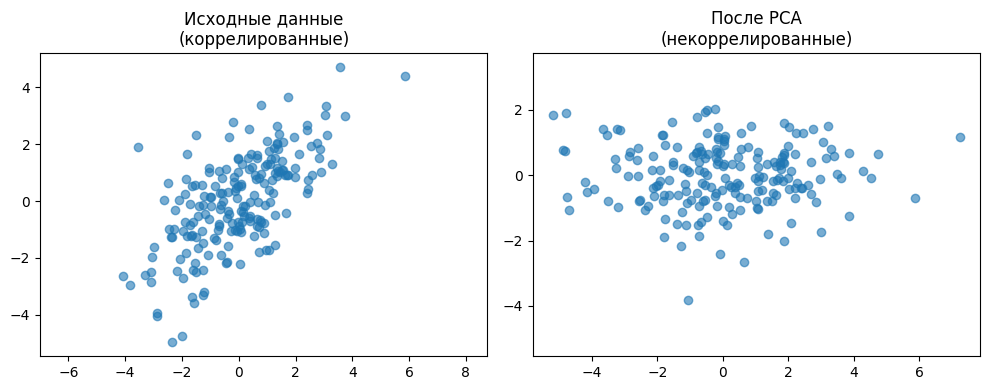

Ковариационная матрица до PCA
[[2.70068227 1.82790453]
 [1.82790453 2.81731696]]

Ковариационная матрица после PCA
[[4.58783418e+00 6.42701972e-16]
 [6.42701972e-16 9.30165045e-01]]


In [4]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

np.random.seed(42)
A = np.array([[3, 2], [2, 3]])
X = np.random.multivariate_normal(mean=[0, 0], cov=A, size=200)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title("Исходные данные\n(коррелированные)")
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.title("После PCA\n(некоррелированные)")
plt.axis("equal")

plt.tight_layout()
plt.show()

print("Ковариационная матрица до PCA")
print(np.cov(X.T))
print("\nКовариационная матрица после PCA")
print(np.cov(X_pca.T))

## Проверка результата

В первой части численно проверяются значения операции $\star$ для двух конкретных входов. Во второй части сравниваются ковариационные матрицы до и после PCA: исходная матрица имеет ненулевые внедиагональные элементы, а после PCA — практически диагональная. Это подтверждает, что главные компоненты действительно некоррелированы.

## Вывод

Бинарная операция $\star$ иллюстрирует общий приём: переход к новой системе координат (или к новой переменной) может существенно упростить вычисления. В линейной алгебре эту роль играет PCA, который диагонализует ковариационную матрицу данных и тем самым упрощает последующий анализ и обучение моделей машинного обучения.
